# One-Stage Exploration (All Splits, One Shot)

This notebook runs **one-stage integrated OSR only** across splits `a,b,c,d` in one run.

Outputs include:
- per-split full sweep
- per-split best-per-method
- overall mean/std across splits


In [11]:
# Cell 1: Repo sync + imports
import os, sys, subprocess
from pathlib import Path

REPO = Path('/content/FYP-code')
URL = 'https://github.com/spinelessknave8/FYP_code.git'

if not REPO.exists():
    subprocess.check_call(['git','clone',URL,str(REPO)])
else:
    subprocess.check_call(['git','-C',str(REPO),'fetch','origin'])
    subprocess.check_call(['git','-C',str(REPO),'reset','--hard','origin/main'])

os.chdir(REPO)
if str(REPO) not in sys.path:
    sys.path.insert(0, str(REPO))

print('cwd:', Path.cwd())
print(subprocess.check_output(['git','-C',str(REPO),'log','--oneline','-n','2'], text=True))


cwd: /content/FYP-code
30bbca1 loop all splits for running new models
cac4b84 now doing one stage integrated exploration with different scoring methods



In [12]:
# Cell 2: Preflight
import platform, numpy as np, torch, torchvision, sklearn
print('python:', platform.python_version())
print('numpy:', np.__version__)
print('torch:', torch.__version__)
print('torchvision:', torchvision.__version__)
print('sklearn:', sklearn.__version__)
print('cuda:', torch.cuda.is_available())


python: 3.12.12
numpy: 2.0.2
torch: 2.10.0+cu128
torchvision: 0.25.0+cu128
sklearn: 1.6.1
cuda: True


In [13]:
# Cell 3: Mount Drive + settings
from google.colab import drive
from pathlib import Path
import shutil

drive.mount('/content/drive')

# ---- run settings ----
SPLITS = ['a','b','c','d']
SEED = 42
HARD_RESET = False
OUT = Path('/content/drive/MyDrive/fyp_outputs/severstral_one_stage_pilot_all_splits')

# pilot sizes
NORMAL_TRAIN_MAX = 1200
NORMAL_VAL_MAX = 250
NORMAL_TEST_MAX = 350
KNOWN_TRAIN_PER_CLASS = 180
KNOWN_VAL_PER_CLASS = 60
KNOWN_TEST_PER_CLASS = 100
UNKNOWN_TEST_MAX = 300

# threshold targets
FPR_TARGETS = [0.05, 0.10, 0.20]
MODEL_SELECT_FPR = 0.10
UNKNOWN_FPR_ON_KNOWN_TARGET = 0.10

sev = Path('/content/drive/MyDrive/datasets/severstal')
assert sev.exists(), f'Missing {sev}'
assert (sev/'train.csv').exists(), 'Missing train.csv'
assert (sev/'train_images').exists(), 'Missing train_images'

if HARD_RESET and OUT.exists():
    shutil.rmtree(OUT)
OUT.mkdir(parents=True, exist_ok=True)
print('OUT:', OUT)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
OUT: /content/drive/MyDrive/fyp_outputs/severstral_one_stage_pilot_all_splits


In [14]:
# Cell 4: One-shot all-split run (train -> embeddings -> sweep)
import json, random, time
from collections import defaultdict
from pathlib import Path
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
from sklearn.metrics import roc_auc_score, accuracy_score, precision_recall_fscore_support, confusion_matrix
from sklearn.neighbors import NearestNeighbors
from sklearn.svm import OneClassSVM
from sklearn.ensemble import IsolationForest
from scipy.special import logsumexp

import yaml
sys.path.insert(0, str(Path('severstral-osr/src').resolve()))
from data import collect_single_label_defect_samples, collect_normal_image_paths, stratified_split
from src.models.resnet50 import build_resnet50
from src.models.embedding import EmbeddingExtractor
from src.osr.gaussian_mahalanobis import fit_gaussians, batch_min_mahalanobis

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]
TF = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])
device = 'cuda' if torch.cuda.is_available() else 'cpu'

# fallback if Cell 3 was not rerun after reconnect
if 'UNKNOWN_KNOWN_FPR_GRID' not in globals():
    UNKNOWN_KNOWN_FPR_GRID = [0.05, 0.10, 0.15, 0.20]


class ImgDS(Dataset):
    def __init__(self, items, class_to_idx=None):
        self.items = items
        self.class_to_idx = class_to_idx
    def __len__(self):
        return len(self.items)
    def __getitem__(self, i):
        p,c = self.items[i]
        x = TF(Image.open(p).convert('RGB'))
        if self.class_to_idx is None:
            return x, c
        return x, self.class_to_idx[c]

def tau_from_fpr(normal_scores, fpr_target):
    return float(np.quantile(normal_scores, 1.0 - fpr_target))

def eval_screening(S_n, S_k, S_u, tau):
    fpr_normal = float(np.mean(S_n > tau))
    tpr_defect = float(np.mean(np.concatenate([S_k,S_u]) > tau))
    return fpr_normal, tpr_defect

def eval_three_way(y3_true, S_n, S_k, S_u, tau, U_k, U_u, u_tau):
    pred_n = np.where(S_n > tau, 1, 0)
    y_n = np.where(pred_n==0, 0, 1)

    known_is_def = S_k > tau
    known_is_unknown = U_k > u_tau
    y_k = np.where(~known_is_def, 0, np.where(known_is_unknown, 2, 1))

    unk_is_def = S_u > tau
    unk_is_unknown = U_u > u_tau
    y_u = np.where(~unk_is_def, 0, np.where(unk_is_unknown, 2, 1))

    y3_pred = np.concatenate([y_n, y_k, y_u])
    acc = float(accuracy_score(y3_true, y3_pred))
    prec, rec, f1, _ = precision_recall_fscore_support(y3_true, y3_pred, average='macro', zero_division=0)
    cm = confusion_matrix(y3_true, y3_pred, labels=[0,1,2]).tolist()
    tpr_unknown_within_defect = float(np.mean(y_u == 2))
    fpr_known_as_unknown = float(np.mean(y_k == 2))
    return {
        'acc_3way': acc,
        'macro_precision_3way': float(prec),
        'macro_recall_3way': float(rec),
        'macro_f1_3way': float(f1),
        'tpr_unknown_within_defect': tpr_unknown_within_defect,
        'fpr_known_as_unknown': fpr_known_as_unknown,
        'cm_3way': cm,
    }

def method_scores(method, params, NTR, NVAL, NTEST, KTR, KVAL, KTEST, UTEST, y_ktr, log_nval, log_ntest, log_kval, log_ktest, log_utest):
    if method == 'global_mahalanobis':
        reg = float(params['cov_reg'])
        mu = NTR.mean(axis=0)
        cov = np.cov(NTR, rowvar=False) + reg*np.eye(NTR.shape[1])
        inv = np.linalg.inv(cov)
        f = lambda X: np.sum(((X - mu) @ inv) * (X - mu), axis=1)
        return f(NVAL), f(NTEST), f(KVAL), f(KTEST), f(UTEST)

    if method == 'global_knn':
        k = int(params['k'])
        nnm = NearestNeighbors(n_neighbors=k, metric='euclidean').fit(NTR)
        f = lambda X: nnm.kneighbors(X)[0].mean(axis=1)
        return f(NVAL), f(NTEST), f(KVAL), f(KTEST), f(UTEST)

    if method == 'one_class_svm_rbf':
        m = OneClassSVM(kernel='rbf', nu=float(params['nu']), gamma=params['gamma'])
        m.fit(NTR)
        f = lambda X: -m.decision_function(X)
        return f(NVAL), f(NTEST), f(KVAL), f(KTEST), f(UTEST)

    if method == 'isolation_forest':
        m = IsolationForest(n_estimators=int(params['n_estimators']), max_samples=params['max_samples'], contamination=float(params['contamination']), random_state=SEED, n_jobs=-1)
        m.fit(NTR)
        f = lambda X: -m.score_samples(X)
        return f(NVAL), f(NTEST), f(KVAL), f(KTEST), f(UTEST)

    if method == 'energy_score':
        T = float(params['temperature'])
        f = lambda logits: -T * logsumexp(logits / T, axis=1)
        return f(log_nval), f(log_ntest), f(log_kval), f(log_ktest), f(log_utest)

    if method == 'class_conditional_mahalanobis':
        reg = float(params['cov_reg'])
        p = fit_gaussians(KTR, y_ktr, reg)
        return batch_min_mahalanobis(NVAL,p), batch_min_mahalanobis(NTEST,p), batch_min_mahalanobis(KVAL,p), batch_min_mahalanobis(KTEST,p), batch_min_mahalanobis(UTEST,p)

    raise ValueError(method)

search_space = {
    'global_mahalanobis': [{'cov_reg':1e-4},{'cov_reg':1e-3},{'cov_reg':1e-2}],
    'global_knn': [{'k':3},{'k':5},{'k':11},{'k':21}],
    'one_class_svm_rbf': [{'nu':0.01,'gamma':'scale'},{'nu':0.05,'gamma':'scale'},{'nu':0.10,'gamma':'scale'},{'nu':0.05,'gamma':0.01},{'nu':0.05,'gamma':0.001}],
    'isolation_forest': [{'n_estimators':100,'max_samples':'auto','contamination':0.05},{'n_estimators':300,'max_samples':'auto','contamination':0.05},{'n_estimators':300,'max_samples':0.5,'contamination':0.10}],
    'energy_score': [{'temperature':1.0},{'temperature':2.0},{'temperature':5.0}],
    'class_conditional_mahalanobis': [{'cov_reg':1e-4},{'cov_reg':1e-3},{'cov_reg':1e-2}],
}

all_rows = []
best_rows = []

for SPLIT in SPLITS:
    print(f'\n===== SPLIT {SPLIT} =====')
    split_out = OUT / f'split_{SPLIT}'
    split_out.mkdir(parents=True, exist_ok=True)

    rng = random.Random(SEED)
    base = yaml.safe_load(Path('severstral-osr/configs/default.yaml').read_text())
    split_cfg = yaml.safe_load(Path(f'severstral-osr/configs/split_{SPLIT}.yaml').read_text())
    base.update(split_cfg)
    known_classes = base['known_classes']
    all_classes = [f'Class_{i}' for i in [1,2,3,4]]
    unknown_class = [c for c in all_classes if c not in known_classes][0]

    samples = collect_single_label_defect_samples(str(sev), 'train.csv', 'train_images')
    normal_paths = collect_normal_image_paths(str(sev), 'train.csv', 'train_images')

    known_samples = [s for s in samples if s[1] in known_classes]
    unknown_samples = [s for s in samples if s[1] == unknown_class]

    k_train_all, k_val_all, k_test_all = stratified_split(known_samples, train_ratio=0.7, val_ratio=0.15, seed=SEED)

    by_cls_train = defaultdict(list); by_cls_val = defaultdict(list); by_cls_test = defaultdict(list)
    for p,c in k_train_all: by_cls_train[c].append((p,c))
    for p,c in k_val_all: by_cls_val[c].append((p,c))
    for p,c in k_test_all: by_cls_test[c].append((p,c))

    known_train=[]; known_val=[]; known_test=[]
    for c in known_classes:
        rng.shuffle(by_cls_train[c]); rng.shuffle(by_cls_val[c]); rng.shuffle(by_cls_test[c])
        known_train += by_cls_train[c][:KNOWN_TRAIN_PER_CLASS]
        known_val += by_cls_val[c][:KNOWN_VAL_PER_CLASS]
        known_test += by_cls_test[c][:KNOWN_TEST_PER_CLASS]

    rng.shuffle(normal_paths)
    normal_train = normal_paths[:NORMAL_TRAIN_MAX]
    normal_val = normal_paths[NORMAL_TRAIN_MAX:NORMAL_TRAIN_MAX+NORMAL_VAL_MAX]
    normal_test = normal_paths[NORMAL_TRAIN_MAX+NORMAL_VAL_MAX:NORMAL_TRAIN_MAX+NORMAL_VAL_MAX+NORMAL_TEST_MAX]

    rng.shuffle(unknown_samples)
    unknown_test = unknown_samples[:UNKNOWN_TEST_MAX]

    # classifier train
    class_to_idx = {c:i for i,c in enumerate(known_classes)}
    train_loader = DataLoader(ImgDS(known_train, class_to_idx), batch_size=32, shuffle=True, num_workers=2)
    val_loader = DataLoader(ImgDS(known_val, class_to_idx), batch_size=32, shuffle=False, num_workers=2)

    model = build_resnet50(num_classes=len(class_to_idx), pretrained=True).to(device)
    opt = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
    crit = nn.CrossEntropyLoss()

    best_val=-1.0; best_state=None
    for ep in range(6):
        model.train()
        for x,y in train_loader:
            x,y=x.to(device), y.to(device)
            opt.zero_grad(); logits=model(x); loss=crit(logits,y); loss.backward(); opt.step()
        model.eval(); va_c=0; va_n=0
        with torch.no_grad():
            for x,y in val_loader:
                x,y=x.to(device), y.to(device)
                l=model(x)
                va_c += (l.argmax(1)==y).sum().item(); va_n += x.size(0)
        va = va_c/max(1,va_n)
        if va>best_val:
            best_val=va
            best_state={k:v.cpu() for k,v in model.state_dict().items()}
    model.load_state_dict(best_state)
    model.to(device).eval()
    extractor = EmbeddingExtractor(model).to(device)

    def infer(items):
        loader = DataLoader(ImgDS(items, None), batch_size=32, shuffle=False, num_workers=2)
        embs, logs, raws = [], [], []
        with torch.no_grad():
            for x,raw in loader:
                x=x.to(device)
                logits=model(x)
                emb=extractor(x)
                embs.append(emb.cpu().numpy())
                logs.append(logits.cpu().numpy())
                raws += list(raw)
        return np.concatenate(embs), np.concatenate(logs), raws

    NTR, _, _ = infer([(p,'normal') for p in normal_train])
    NVAL, LOG_NVAL, _ = infer([(p,'normal') for p in normal_val])
    NTEST, LOG_NTEST, _ = infer([(p,'normal') for p in normal_test])
    KTR, _, RAW_KTR = infer(known_train)
    KVAL, LOG_KVAL, RAW_KVAL = infer(known_val)
    KTEST, LOG_KTEST, RAW_KTEST = infer(known_test)
    UTEST, LOG_UTEST, RAW_UTEST = infer(unknown_test)

    y_ktr = np.array([class_to_idx[r] for r in RAW_KTR], dtype=np.int64)

    # unknown scorer calibration pool (swept by known-FPR grid)
    known_params = fit_gaussians(KTR, y_ktr, 1e-3)
    U_VAL = batch_min_mahalanobis(KVAL, known_params)
    U_TEST_K = batch_min_mahalanobis(KTEST, known_params)
    U_TEST_U = batch_min_mahalanobis(UTEST, known_params)

    y3_true = np.concatenate([
        np.zeros(len(NTEST), dtype=np.int64),
        np.ones(len(KTEST), dtype=np.int64),
        np.full(len(UTEST), 2, dtype=np.int64),
    ])

    split_rows=[]
    for method, plist in search_space.items():
        for p in plist:
            S_n_val, S_n_test, S_k_val, S_k_test, S_u_test = method_scores(method, p, NTR, NVAL, NTEST, KTR, KVAL, KTEST, UTEST, y_ktr, LOG_NVAL, LOG_NTEST, LOG_KVAL, LOG_KTEST, LOG_UTEST)

            tau_sel = tau_from_fpr(S_n_val, MODEL_SELECT_FPR)
            fpr_sel, tpr_sel = eval_screening(S_n_val, S_k_val, S_k_val[:0], tau_sel)

            y_bin = np.concatenate([np.zeros(len(S_n_test)), np.ones(len(S_k_test)+len(S_u_test))])
            s_bin = np.concatenate([S_n_test, S_k_test, S_u_test])
            auroc = float(roc_auc_score(y_bin, s_bin)) if len(np.unique(y_bin))>1 else float('nan')

            for fpr_t in FPR_TARGETS:
                tau = tau_from_fpr(S_n_val, fpr_t)
                fpr_normal, tpr_defect = eval_screening(S_n_test, S_k_test, S_u_test, tau)

                for u_known_fpr in UNKNOWN_KNOWN_FPR_GRID:
                    u_tau = float(np.quantile(U_VAL, 1.0 - u_known_fpr))
                    m3 = eval_three_way(y3_true, S_n_test, S_k_test, S_u_test, tau, U_TEST_K, U_TEST_U, u_tau)
                    row = {
                        'split': f'split_{SPLIT}',
                        'known_classes': ','.join(known_classes),
                        'unknown_class': unknown_class,
                        'method': method,
                        **{f'param_{k}':v for k,v in p.items()},
                        'model_select_tau@val_fpr10': tau_sel,
                        'val_tpr_defect@fpr10': tpr_sel,
                        'screening_auroc_test': auroc,
                        'fpr_target': fpr_t,
                        'tau': tau,
                        'unknown_known_fpr_target': u_known_fpr,
                        'u_tau': u_tau,
                        'fpr_normal': fpr_normal,
                        'tpr_defect': tpr_defect,
                        **m3,
                    }
                    split_rows.append(row)
                    all_rows.append(row)

    split_df = pd.DataFrame(split_rows)
    split_df.to_csv(split_out/'one_stage_scorer_sweep.csv', index=False)

    split_best = (
        split_df[(split_df['fpr_target']==0.10) & (split_df['fpr_known_as_unknown']<=0.15)]
        .sort_values(['method','tpr_unknown_within_defect','macro_f1_3way','tpr_defect'], ascending=[True,False,False,False])
        .groupby('method', as_index=False)
        .head(1)
        .sort_values('macro_f1_3way', ascending=False)
    )

    # fallback if strict filter empties any method
    if split_best['method'].nunique() < len(search_space):
        missing = [m for m in search_space.keys() if m not in set(split_best['method'].tolist())]
        if missing:
            fb = (split_df[(split_df['fpr_target']==0.10) & (split_df['method'].isin(missing))]
                  .sort_values(['method','macro_f1_3way','tpr_defect'], ascending=[True,False,False])
                  .groupby('method', as_index=False)
                  .head(1))
            split_best = pd.concat([split_best, fb], ignore_index=True).sort_values('macro_f1_3way', ascending=False)
    split_best.to_csv(split_out/'one_stage_best_per_method.csv', index=False)
    print('best (split', SPLIT, '):')
    display(split_best[['method','unknown_known_fpr_target','screening_auroc_test','tpr_defect','fpr_normal','tpr_unknown_within_defect','fpr_known_as_unknown','acc_3way','macro_f1_3way']])

    best_rows += split_best.to_dict('records')

# save global
all_df = pd.DataFrame(all_rows)
all_df.to_csv(OUT/'one_stage_scorer_sweep_all_splits.csv', index=False)

best_df = pd.DataFrame(best_rows)
best_df.to_csv(OUT/'one_stage_best_per_method_per_split.csv', index=False)

summary = (best_df
           .groupby('method')[['screening_auroc_test','tpr_defect','fpr_normal','tpr_unknown_within_defect','fpr_known_as_unknown','acc_3way','macro_f1_3way']]
           .agg(['mean','std'])
           .reset_index())
summary.columns = ['_'.join(col).strip('_') for col in summary.columns.values]
summary.to_csv(OUT/'one_stage_method_summary_mean_std.csv', index=False)

print('\nSaved:')
print(OUT/'one_stage_scorer_sweep_all_splits.csv')
print(OUT/'one_stage_best_per_method_per_split.csv')
print(OUT/'one_stage_method_summary_mean_std.csv')





===== SPLIT a =====
best (split a ):


,method,screening_auroc_test,tpr_defect,fpr_normal,tpr_unknown_within_defect,fpr_known_as_unknown,acc_3way,macro_f1_3way
1,global_mahalanobis,0.769078,0.343396,0.077143,0.083333,0.108696,0.511364,0.433331
10,global_knn,0.773305,0.307547,0.082857,0.086667,0.082609,0.477273,0.385497
31,one_class_svm_rbf,0.695181,0.245283,0.068571,0.073333,0.078261,0.469318,0.371089
43,isolation_forest,0.643100,0.183019,0.051429,0.036667,0.078261,0.461364,0.353706
52,energy_score,0.384318,0.035849,0.068571,0.000000,0.026087,0.384091,0.213057
55,class_conditional_mahalanobis,0.346668,0.003774,0.125714,0.000000,0.008696,0.347727,0.172297



===== SPLIT b =====
best (split b ):


,method,screening_auroc_test,tpr_defect,fpr_normal,tpr_unknown_within_defect,fpr_known_as_unknown,acc_3way,macro_f1_3way
7,global_mahalanobis,0.630388,0.216535,0.100000,0.086667,0.086538,0.455711,0.355817
31,one_class_svm_rbf,0.549151,0.165354,0.102857,0.053333,0.081731,0.433566,0.319349
10,global_knn,0.601552,0.120079,0.068571,0.053333,0.072115,0.432401,0.299546
52,energy_score,0.545115,0.151575,0.137143,0.076667,0.019231,0.390443,0.254581
43,isolation_forest,0.485281,0.062992,0.117143,0.023333,0.048077,0.384615,0.231573
55,class_conditional_mahalanobis,0.327047,0.023622,0.085714,0.030000,0.014423,0.383450,0.202192



===== SPLIT c =====
best (split c ):


,method,screening_auroc_test,tpr_defect,fpr_normal,tpr_unknown_within_defect,fpr_known_as_unknown,acc_3way,macro_f1_3way
52,energy_score,0.510112,0.141649,0.177143,0.000000,0.010791,0.405832,0.259816
22,one_class_svm_rbf,0.550396,0.118393,0.140000,0.000000,0.035971,0.414338,0.259383
7,global_mahalanobis,0.460507,0.101480,0.097143,0.005128,0.082734,0.414338,0.243758
37,isolation_forest,0.473555,0.059197,0.094286,0.000000,0.014388,0.414338,0.237809
10,global_knn,0.501782,0.059197,0.085714,0.000000,0.050360,0.405832,0.220316
55,class_conditional_mahalanobis,0.230945,0.000000,0.117143,0.000000,0.000000,0.375456,0.181979



===== SPLIT d =====
best (split d ):


,method,screening_auroc_test,tpr_defect,fpr_normal,tpr_unknown_within_defect,fpr_known_as_unknown,acc_3way,macro_f1_3way
1,global_mahalanobis,0.640759,0.362205,0.137143,0.080000,0.086538,0.460373,0.368646
31,one_class_svm_rbf,0.545321,0.230315,0.111429,0.076667,0.062500,0.438228,0.328086
10,global_knn,0.575849,0.200787,0.105714,0.076667,0.067308,0.432401,0.315966
43,isolation_forest,0.524404,0.206693,0.111429,0.063333,0.043269,0.417249,0.291093
52,energy_score,0.624499,0.078740,0.071429,0.006667,0.004808,0.398601,0.230997
61,class_conditional_mahalanobis,0.298183,0.005906,0.080000,0.003333,0.009615,0.376457,0.184585



Saved:
/content/drive/MyDrive/fyp_outputs/severstral_one_stage_pilot_all_splits/one_stage_scorer_sweep_all_splits.csv
/content/drive/MyDrive/fyp_outputs/severstral_one_stage_pilot_all_splits/one_stage_best_per_method_per_split.csv
/content/drive/MyDrive/fyp_outputs/severstral_one_stage_pilot_all_splits/one_stage_method_summary_mean_std.csv


=== Best per split x method (fpr_target=0.10) ===


,split,method,screening_auroc_test,tpr_defect,fpr_normal,tpr_unknown_within_defect,fpr_known_as_unknown,acc_3way,macro_f1_3way
0,split_a,global_mahalanobis,0.769078,0.343396,0.077143,0.083333,0.108696,0.511364,0.433331
1,split_a,global_knn,0.773305,0.307547,0.082857,0.086667,0.082609,0.477273,0.385497
2,split_a,one_class_svm_rbf,0.695181,0.245283,0.068571,0.073333,0.078261,0.469318,0.371089
3,split_a,isolation_forest,0.643100,0.183019,0.051429,0.036667,0.078261,0.461364,0.353706
4,split_a,energy_score,0.384318,0.035849,0.068571,0.000000,0.026087,0.384091,0.213057
5,split_a,class_conditional_mahalanobis,0.346668,0.003774,0.125714,0.000000,0.008696,0.347727,0.172297
6,split_b,global_mahalanobis,0.630388,0.216535,0.100000,0.086667,0.086538,0.455711,0.355817
7,split_b,one_class_svm_rbf,0.549151,0.165354,0.102857,0.053333,0.081731,0.433566,0.319349
8,split_b,global_knn,0.601552,0.120079,0.068571,0.053333,0.072115,0.432401,0.299546
9,split_b,energy_score,0.545115,0.151575,0.137143,0.076667,0.019231,0.390443,0.254581


=== Mean/Std across splits ===


,method,screening_auroc_test_mean,screening_auroc_test_std,tpr_defect_mean,tpr_defect_std,fpr_normal_mean,fpr_normal_std,tpr_unknown_within_defect_mean,tpr_unknown_within_defect_std,fpr_known_as_unknown_mean,fpr_known_as_unknown_std,acc_3way_mean,acc_3way_std,macro_f1_3way_mean,macro_f1_3way_std
3,global_mahalanobis,0.625183,0.126614,0.255904,0.121589,0.102857,0.025017,0.063782,0.039197,0.091127,0.011849,0.460446,0.039753,0.350388,0.078766
5,one_class_svm_rbf,0.585012,0.073478,0.189836,0.058925,0.105714,0.029416,0.050833,0.035421,0.064616,0.020849,0.438863,0.022785,0.319477,0.046005
2,global_knn,0.613122,0.114860,0.171902,0.107428,0.085714,0.015298,0.054167,0.038718,0.068098,0.013441,0.436977,0.029640,0.305331,0.067825
4,isolation_forest,0.531585,0.077457,0.127975,0.077845,0.093571,0.029727,0.030833,0.026440,0.045999,0.026152,0.419392,0.031629,0.278545,0.056782
1,energy_score,0.516011,0.099991,0.101953,0.054610,0.113571,0.052909,0.020833,0.037355,0.015229,0.009349,0.394742,0.009484,0.239613,0.021692
0,class_conditional_mahalanobis,0.300711,0.050594,0.008325,0.010486,0.102143,0.022663,0.008333,0.014530,0.008184,0.006006,0.370772,0.015770,0.185263,0.012463


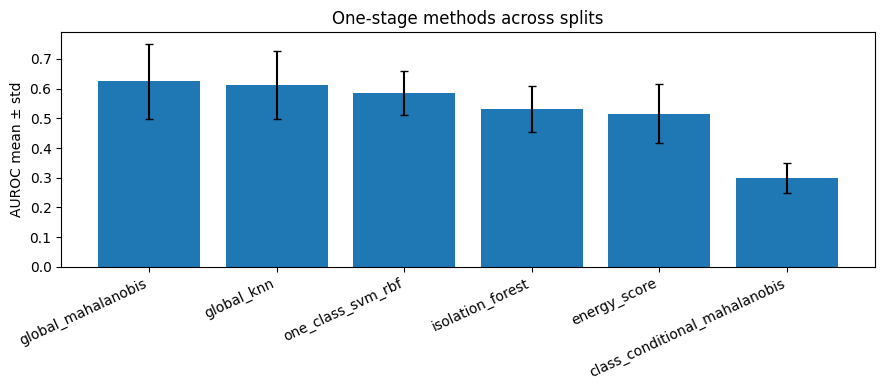

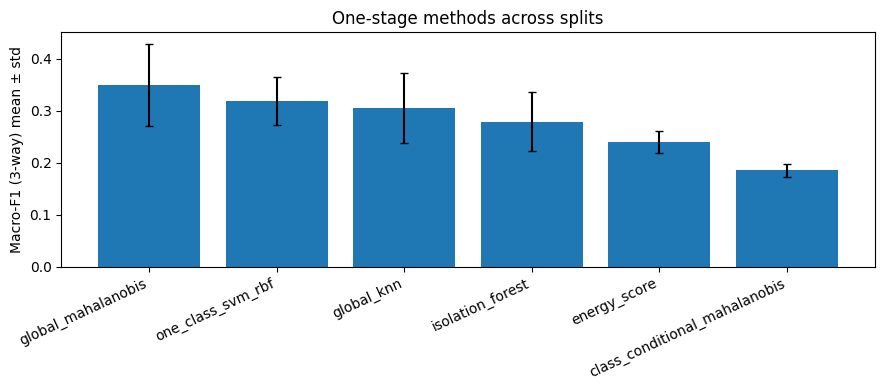

Plots saved in: /content/drive/MyDrive/fyp_outputs/severstral_one_stage_pilot_all_splits


In [15]:
# Cell 5: Final tables + plots
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

all_df = pd.read_csv(OUT/'one_stage_scorer_sweep_all_splits.csv')
best_df = pd.read_csv(OUT/'one_stage_best_per_method_per_split.csv')
summary = pd.read_csv(OUT/'one_stage_method_summary_mean_std.csv')

print('=== Best per split x method (fpr_target=0.10) ===')
display(best_df[['split','method','unknown_known_fpr_target','screening_auroc_test','tpr_defect','fpr_normal','tpr_unknown_within_defect','fpr_known_as_unknown','acc_3way','macro_f1_3way']].sort_values(['split','macro_f1_3way'], ascending=[True,False]))

print('=== Mean/Std across splits ===')
display(summary.sort_values('macro_f1_3way_mean', ascending=False))

# AUROC mean plot
p = summary.sort_values('screening_auroc_test_mean', ascending=False)
plt.figure(figsize=(9,4))
plt.bar(p['method'], p['screening_auroc_test_mean'], yerr=p['screening_auroc_test_std'], capsize=3)
plt.xticks(rotation=25, ha='right')
plt.ylabel('AUROC mean ± std')
plt.title('One-stage methods across splits')
plt.tight_layout()
plt.savefig(OUT/'plot_method_auroc_mean_std.png', dpi=160)
plt.show()

# Macro-F1 mean plot
p2 = summary.sort_values('macro_f1_3way_mean', ascending=False)
plt.figure(figsize=(9,4))
plt.bar(p2['method'], p2['macro_f1_3way_mean'], yerr=p2['macro_f1_3way_std'], capsize=3)
plt.xticks(rotation=25, ha='right')
plt.ylabel('Macro-F1 (3-way) mean ± std')
plt.title('One-stage methods across splits')
plt.tight_layout()
plt.savefig(OUT/'plot_method_macrof1_mean_std.png', dpi=160)
plt.show()

print('Plots saved in:', OUT)



## Output files
- `one_stage_scorer_sweep_all_splits.csv`
- `one_stage_best_per_method_per_split.csv`
- `one_stage_method_summary_mean_std.csv`
- `plot_method_auroc_mean_std.png`
- `plot_method_macrof1_mean_std.png`
